In [1]:
!pip install transformers torch scikit-learn pydantic matplotlib seaborn -q

import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field, ValidationError
import warnings
warnings.filterwarnings('ignore')

print("Окружение готово. GPU:", "Доступен" if torch.cuda.is_available() else "ОШИБКА: Включите GPU!")

Окружение готово. GPU: Доступен


In [2]:
# Наш железобетонный пайплайн из 4-6 уроков
class NomenclatureItem(BaseModel):
    raw_text: str = Field(..., min_length=5)
    target_category: str = Field(..., min_length=2)

file_path = "Выгрузка НП-ЦН 100К.csv"
df_raw = pd.read_csv(file_path, sep=';', encoding='cp1251', on_bad_lines='skip')
df_raw.columns = ['raw_text', 'target_category']
df_raw = df_raw.dropna()

valid_data = []
for idx, row in df_raw.iterrows():
    if "ВЫБЕРИТЕ КОРРЕКТНУЮ ЦН" in str(row['target_category']):
        continue
    try:
        item = NomenclatureItem(
            raw_text=str(row['raw_text']).strip().lower(),
            target_category=str(row['target_category']).strip()
        )
        valid_data.append(item.model_dump())
    except ValidationError:
        pass

df_clean = pd.DataFrame(valid_data)
top_classes = df_clean['target_category'].value_counts().nlargest(50).index
df_baseline = df_clean[df_clean['target_category'].isin(top_classes)].copy()

# Кодируем целевые классы в числа для нейросети
labels_map = {label: i for i, label in enumerate(top_classes)}
reverse_labels_map = {i: label for label, i in labels_map.items()}
df_baseline['label_id'] = df_baseline['target_category'].map(labels_map)

X_train, X_test, y_train, y_test = train_test_split(
    df_baseline['raw_text'].values, df_baseline['label_id'].values,
    test_size=0.2, stratify=df_baseline['label_id'].values, random_state=42
)
print(f"Подготовлено для обучения: {len(X_train)} строк")

Подготовлено для обучения: 8238 строк


In [3]:
def augment_text(text, prob=0.1):
    """Искусственно вносит опечатки (удаление или перестановка случайных символов)"""
    if len(text) < 10 or random.random() > prob:
        return text
    chars = list(text)
    idx = random.randint(0, len(chars)-2)
    if random.random() > 0.5:
        # Перестановка (typo)
        chars[idx], chars[idx+1] = chars[idx+1], chars[idx]
    else:
        # Удаление
        chars.pop(idx)
    return "".join(chars)

# Аугментируем только Train выборку!
X_train_aug = [augment_text(text, prob=0.3) for text in X_train]

print("Пример аугментации:")
print("Оригинал:", X_train[0])
print("С мусором:", X_train_aug[0])

Пример аугментации:
Оригинал: арматура ф 10 а240с гост 34028
С мусором: арматура ф 10 а240с гост 34028


In [5]:
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Создаем Dataset для PyTorch
class NSIDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        inputs = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors="pt")
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

train_dataset = NSIDataset(X_train_aug, y_train, tokenizer) # Используем аугментированные!
eval_dataset = NSIDataset(X_test, y_test, tokenizer)

# Инициализируем модель С ГОЛОВОЙ КЛАССИФИКАТОРА (50 классов)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=50)

# Настройки обучения (HuggingFace Trainer)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,             # 5 эпох для надежности
    per_device_train_batch_size=64, # Оптимально для tiny-версии
    per_device_eval_batch_size=128,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,             # Стандартный шаг для BERT
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'f1_weighted': f1_score(labels, predictions, average='weighted')}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

print("Начинаю дообучение RuBERT-tiny2... Это займет несколько минут.")
trainer.train()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Начинаю дообучение RuBERT-tiny2... Это займет несколько минут.


Epoch,Training Loss,Validation Loss,F1 Weighted
1,No log,2.193189,0.415899
2,No log,1.858106,0.479079
3,No log,1.696226,0.551932
4,2.106567,1.611990,0.564164
5,2.106567,1.586506,0.578377


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=645, training_loss=1.9967019724291424, metrics={'train_runtime': 53.5876, 'train_samples_per_second': 768.647, 'train_steps_per_second': 12.036, 'total_flos': 38205582174720.0, 'train_loss': 1.9967019724291424, 'epoch': 5.0})

--- Оценка модели и Постобработка ---


Позиций отправлено на ручной разбор экспертом (<0.85 уверенности): 1165 из 2060
F1-Weighted на автоматически сопоставленных данных: 0.9285


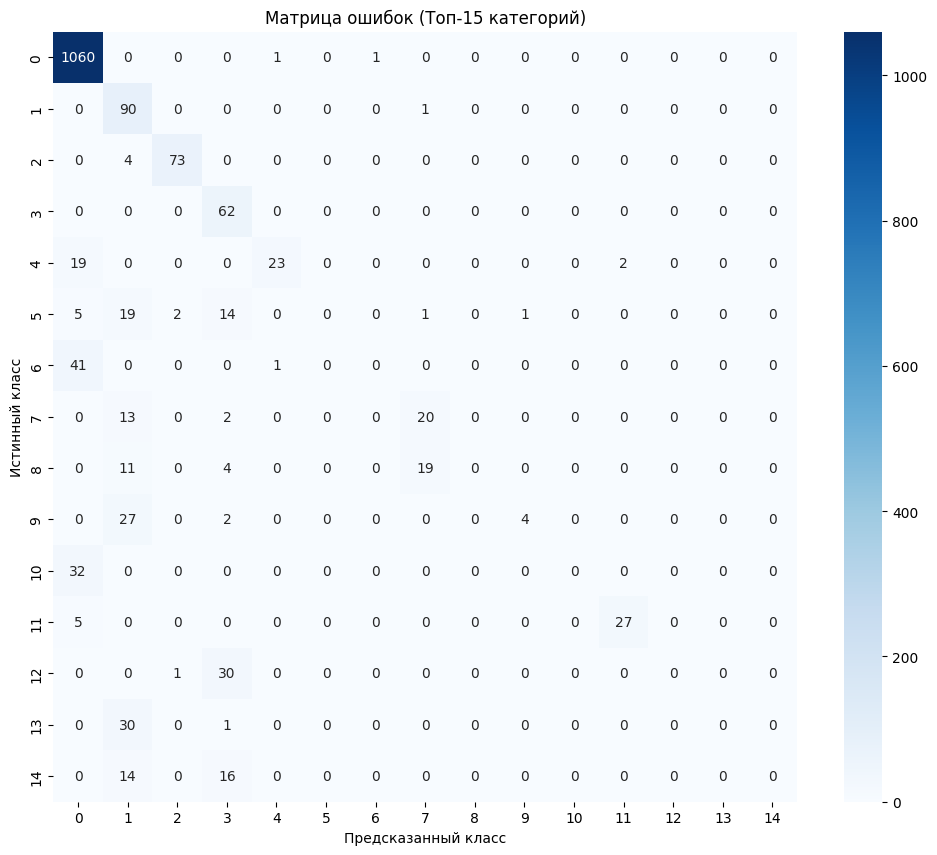


ВЫВОД:
Модель успешно дообучена под специфический словарь НСИ. Добавлен модуль постобработки: неуверенные предсказания блокируются, что страхует систему 1С от ошибочного авто-сопоставления.


In [6]:
print("--- Оценка модели и Постобработка ---")
predictions = trainer.predict(eval_dataset)
logits = predictions.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# Получаем классы и максимальные вероятности (Confidence)
pred_classes = np.argmax(probs, axis=1)
confidence_scores = np.max(probs, axis=1)

# БИЗНЕС-ЛОГИКА ПОСТОБРАБОТКИ (Threshold = 0.85)
THRESHOLD = 0.85
final_predictions = []
manual_review_count = 0

for i in range(len(pred_classes)):
    if confidence_scores[i] >= THRESHOLD:
        final_predictions.append(pred_classes[i])
    else:
        final_predictions.append(-1) # Маркер ручного разбора
        manual_review_count += 1

print(f"Позиций отправлено на ручной разбор экспертом (<{THRESHOLD} уверенности): {manual_review_count} из {len(y_test)}")

# Считаем метрики только для автоматизированных позиций
mask = np.array(final_predictions) != -1
if np.sum(mask) > 0:
    auto_f1 = f1_score(y_test[mask], np.array(final_predictions)[mask], average='weighted')
    print(f"F1-Weighted на автоматически сопоставленных данных: {auto_f1:.4f}")

# ВИЗУАЛИЗАЦИЯ: Матрица ошибок для Топ-15 классов (чтобы график был читаемым)
top_15_labels = list(range(15))
cm = confusion_matrix(y_test, pred_classes, labels=top_15_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Топ-15 категорий)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("\nВЫВОД:")
print("Модель успешно дообучена под специфический словарь НСИ. Добавлен модуль постобработки: "
      "неуверенные предсказания блокируются, что страхует систему 1С от ошибочного авто-сопоставления.")